# 47 - Milestone Project: Heart Disease Classification

**Section:** FNN Milestone Projects | **Prereqs:** all of `Metaparameters/` and `Model Evaluation/` | **Next:** `FNN Milestone Projects/FNN_Adding Machine.ipynb`

The first end-to-end project on real medical data (UCI heart disease, 303
patients, 13 clinical features). Everything from the course so far, in one place:
missing-value handling, per-column scaling, batch norm, dropout, weight decay,
class weighting, and evaluation by confusion matrix rather than accuracy.

**The one idea that is new here: `pos_weight`.** `BCEWithLogitsLoss(pos_weight=w)`
multiplies the loss contribution of positive samples by `w`. Set
`w = negatives/positives` and a rare class counts as much in the loss as a common
one. It is the cleanest fix for imbalance - it needs no resampling and no extra
data.

**Why recall matters more than accuracy here.** Missing a patient who has heart
disease (a false negative) is far worse than a false alarm. The threshold and the
`pos_weight` should both be tuned with that asymmetry in mind - which is a
clinical judgement, not a modelling one.

**Also demonstrated:** scaling only the continuous columns and leaving the
already-binary ones (`sex`, `fbs`, `exang`) alone. Standardising a 0/1 column
does no harm mathematically but destroys its interpretability.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report

!pip install ucimlrepo

In [44]:
# UCI heart disease. The target is 0-4 (severity), not a binary flag.
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

X['target'] = y
X.shape

(303, 14)

In [45]:
# Drop rows with missing values. With only 303 patients, dropping loses real
# information - imputation (median, or a model) is usually better on a dataset
# this small.
X = X.dropna()

In [46]:
X.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [47]:
# value_counts on the whole frame - a quick look for duplicate rows.
X.value_counts()

age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca   thal  target
77   1    4   125       304   0    2        162      1      0.0      1      3.0  3.0   4         1
29   1    2   130       204   0    2        202      0      0.0      1      0.0  3.0   0         1
34   0    2   118       210   0    0        192      0      0.7      1      0.0  3.0   0         1
     1    1   118       182   0    2        174      0      0.0      1      0.0  3.0   0         1
35   0    4   138       183   0    0        182      0      1.4      1      0.0  3.0   0         1
                                                                                                ..
39   1    4   118       219   0    0        140      0      1.2      2      0.0  7.0   3         1
          3   140       321   0    2        182      0      0.0      1      0.0  3.0   0         1
     0    3   138       220   0    0        152      0      0.0      2      0.0  3.0   0         1
              94        199   0    0        179      0      0.0      1      0.0  3.0   0         1
38   1    1   120       231   0    0        182      1      3.8      2      0.0  7.0   4         1
Name: count, Length: 297, dtype: int64

In [48]:
# describe() gives the ranges: some features are 0/1 flags and others run into
# the hundreds, which is why scaling comes next.
X.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,3.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,1.602694,0.676768,4.730640,0.946128
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,1.938629,1.234551
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000


In [49]:
y = X['target']
X = X.drop(columns=['target'], axis=1)
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
297,57,0,4,140,241,0,0,123,1,0.2,2,0.0,7.0
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0


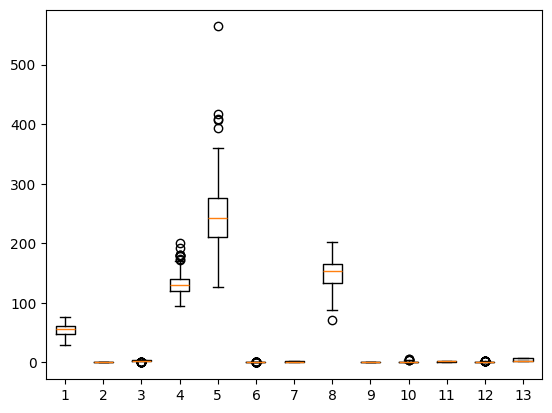

In [50]:
# Box plots before scaling: chol and trestbps dominate everything else purely
# by magnitude.
plt.boxplot(X);

In [51]:
# The target distribution across severity levels 0-4.
y.value_counts()

,count
target,
0,160
1,54
2,35
3,35
4,13


In [52]:
# Binarise: severity > 1 becomes 'disease'. A modelling choice - a different
# threshold gives a different (and differently balanced) problem.

mask = (y > 1).values
type(mask)

numpy.ndarray

In [53]:
y

,target
0,0
1,2
2,1
3,0
4,0
...,...
297,1
298,1
299,2
300,3


In [54]:
X.shape

(297, 13)

In [55]:
# The binary target as a float column vector (N,1), which is the shape
# BCEWithLogitsLoss expects.
# Convert the boolean mask to a PyTorch tensor on CPU, then move to GPU and convert to float
y = torch.tensor(mask, dtype=torch.bool).unsqueeze(1).to('cuda').float()
pd.DataFrame(y.detach().cpu().numpy()).value_counts()

,count
0,
0.0,214
1.0,83


In [56]:
# Split, then compute pos_weight = negatives/positives FROM THE TRAINING SPLIT
# only. Passed to BCEWithLogitsLoss, it scales up the loss on positive samples
# so the rare class is not ignored.
# The 1e-8 guards against division by zero if a split happens to contain no
# positives.
X_train, X_test, Y_train, Y_test = train_test_split(X,y,test_size=97, shuffle=True)
# Calculate pos_weight based on the binary target
pos = Y_train.sum()
neg = len(Y_train) - pos
pos_weight = (neg / (pos + 1e-8)).to('cuda')

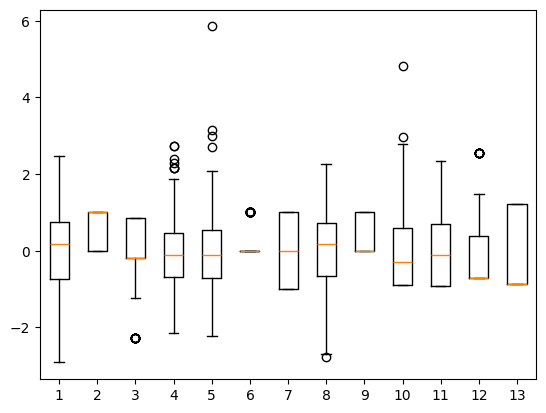

In [57]:
# Scale only the CONTINUOUS columns. The binary flags (sex, fbs, exang) are
# left as 0/1 - standardising them would work but makes them unreadable.
# fit on train, transform on test: the correct order.
cols_to_transform = ['trestbps'	,'chol', 'thalach', 'age','cp',		'restecg',		"oldpeak", 	'slope', 'ca',	'thal']

scaler = StandardScaler()

X_train[cols_to_transform] = scaler.fit_transform(X_train[cols_to_transform])

X_test[cols_to_transform] = scaler.transform(X_test[cols_to_transform])

plt.boxplot(X_train);

In [58]:
pd.DataFrame(X_train)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
230,-0.285539,0,-0.188941,0.231283,-0.933041,0,1.005038,0.804949,0,-0.794864,0.709619,-0.722532,-0.862480
78,-0.743318,1,-1.238611,-0.110094,-0.029503,0,1.005038,1.290923,0,-0.702919,0.709619,-0.722532,-0.862480
193,0.858907,0,0.860729,0.345076,0.874035,1,-1.005038,-1.978355,0,0.860145,0.709619,2.561703,-0.862480
243,0.744463,1,-2.288280,0.117491,-0.232338,0,-1.005038,-0.255357,0,1.503760,0.709619,1.466958,-0.862480
283,-2.231099,1,-1.238611,-0.565264,-1.006799,0,-1.005038,1.025847,0,-0.886809,-0.921689,-0.722532,-0.862480
...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,-1.658875,1,0.860729,1.141623,-0.435173,0,-1.005038,1.335103,0,-0.886809,-0.921689,-0.722532,1.215785
118,0.973352,1,0.860729,-0.110094,1.537858,1,1.005038,-0.829690,1,0.768200,-0.921689,2.561703,1.215785
256,1.431131,0,0.860729,-1.475604,-0.435173,0,-1.005038,-0.387895,0,-0.610974,-0.921689,1.466958,-0.862480
272,-0.972207,1,0.860729,0.458868,1.187507,0,-1.005038,-1.359843,1,0.768200,0.709619,1.466958,1.215785


In [59]:
X_train.shape, Y_train.shape

((200, 13), torch.Size([200, 1]))

In [60]:
X_train = torch.tensor(X_train.to_numpy(),dtype=torch.float,device='cuda')
X_test = torch.tensor(X_test.to_numpy(),dtype=torch.float,device='cuda')

In [61]:
# Loaders. drop_last=True matters more than usual here: batch norm needs at
# least 2 samples per batch, and a final batch of 1 would raise.
train_tensor = TensorDataset(X_train, Y_train)
test_tensor = TensorDataset(X_test, Y_test)

bs = 64
train_loader = DataLoader(train_tensor, batch_size=bs, shuffle = True, drop_last=True)
val_loader = DataLoader(test_tensor,batch_size=test_tensor.tensors[0].shape[0])

In [72]:
# 13 -> 64 -> 32 -> 10 -> 1 with batch norm after every layer and LeakyReLU.
# Dropout is applied after the two hidden activations - declaring a layer in
# __init__ does nothing on its own; only calling it in forward has any effect.
class classifier(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(13, 64)
    self.bnorm0 = nn.BatchNorm1d(64)

    self.fc1 = nn.Linear(64,32)
    self.bnorm1 = nn.BatchNorm1d(32)

    self.fc2 = nn.Linear(32,10)
    self.bnorm2 = nn.BatchNorm1d(10)

    self.drop = nn.Dropout(p=0.5)

    self.out_layer = nn.Linear(10,1)


  def forward(self,x):

    x = F.leaky_relu(self.bnorm0(self.input_layer(x)))
    x = self.drop(x)

    x = F.leaky_relu(self.bnorm1(self.fc1(x)))
    x = self.drop(x)

    x = F.leaky_relu(self.bnorm2(self.fc2(x)))

    return self.out_layer(x)

In [77]:
# The full recipe: BCEWithLogitsLoss with pos_weight for imbalance, Adam for
# robustness to learning rate, weight_decay=1e-4 for L2.
# Note that with pos_weight the loss VALUE is no longer comparable to an
# unweighted run - only its trend is meaningful.
def train_model():

  model = classifier().to('cuda')

  epochs = 250

  lossFunc = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

  optimizer = torch.optim.Adam(model.parameters(), lr=1e-4,weight_decay=1e-4)


  train_acc = []
  val_acc = []
  losses = []

  for epoch in range(epochs):

    model.train()

    batch_acc = []
    batch_loss = []

    for x,y in train_loader:

      yhat = model(x)

      loss = lossFunc(yhat, y)
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


      batch_acc.append( 100 * torch.mean( ((yhat > 0) == y).float() ).cpu() )


    train_acc.append(np.mean(batch_acc))
    losses.append(np.mean(batch_loss))

    # Validation eval

    model.eval()
    with torch.no_grad():

      a,b = next(iter(val_loader))
      preds = model(a)
      val_acc.append( 100 * torch.mean( ((preds  > 0) == b).float() ).cpu())


    if epoch % 50 == 0 or epoch == epochs-1:
      print(f'Epoch {epoch} | Loss : {losses[epoch]} | Train_acc : {train_acc[epoch]} | Val Acc : {val_acc[epoch]}')

  return train_acc, val_acc , losses, model

In [78]:
train_acc, val_acc , losses, model = train_model()

Epoch 0 | Loss : 1.046834905942281 | Train_acc : 56.25 | Val Acc : 71.13401794433594
Epoch 50 | Loss : 0.7267653346061707 | Train_acc : 89.0625 | Val Acc : 69.0721664428711
Epoch 100 | Loss : 0.6253978808720907 | Train_acc : 90.10416412353516 | Val Acc : 73.19587707519531
Epoch 150 | Loss : 0.5592470367749532 | Train_acc : 92.70833587646484 | Val Acc : 74.22679901123047
Epoch 200 | Loss : 0.5000572502613068 | Train_acc : 95.3125 | Val Acc : 75.25772857666016
Epoch 249 | Loss : 0.4584800899028778 | Train_acc : 94.27083587646484 | Val Acc : 75.25772857666016


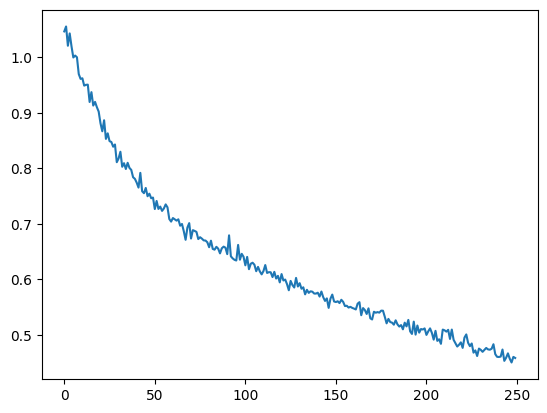

In [79]:
# Loss curve.
plt.plot(losses);

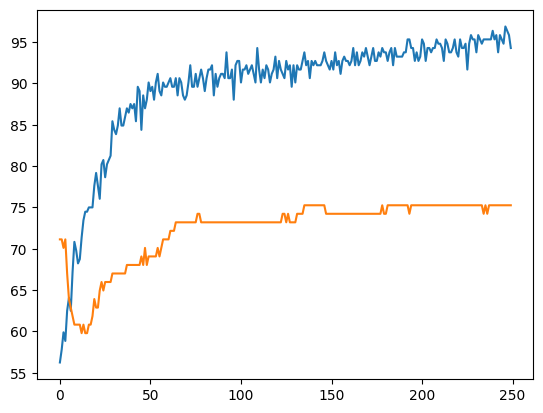

In [80]:
# Train vs validation accuracy. With a small dataset expect a noisy validation
# curve - 97 samples means one patient is worth a full percentage point.
plt.plot(train_acc);
plt.plot(val_acc);

In [81]:
# Predictions on the validation set at threshold logit > 0.
a, b = next(iter(val_loader))
preds = (model(a) > 0)

In [82]:
# The confusion matrix, with sklearn's (y_true, y_pred) order so rows are the
# truth and columns the prediction.
# On medical data read the FALSE NEGATIVE cell first - row 1, column 0: the
# patients who have the disease and were cleared by the model.
matrix = confusion_matrix(b.cpu(), preds.cpu().detach())
matrix

array([[51,  6],
       [18, 22]])

In [83]:
# classification_report. Recall on the positive class is the number that
# matters for a screening tool.
print(classification_report(b.cpu(), preds.cpu().detach()))

              precision    recall  f1-score   support

       False       0.74      0.89      0.81        57
        True       0.79      0.55      0.65        40

    accuracy                           0.75        97
   macro avg       0.76      0.72      0.73        97
weighted avg       0.76      0.75      0.74        97



In [84]:
# Final validation accuracy - report it alongside recall, never alone.
val_acc[-1]

tensor(75.2577)

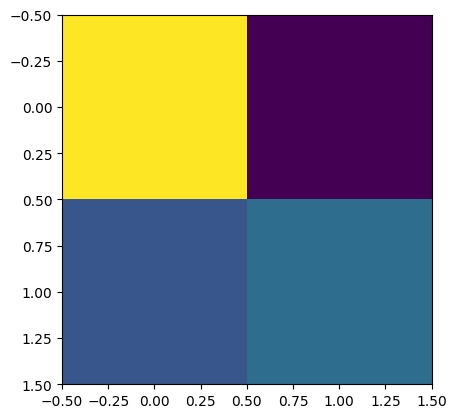

In [85]:
# The confusion matrix as an image.
plt.imshow(matrix);